---
# La poule qui chante  
### Étude de marché international pour les *Poulets Agriculture Biologique*  
#### Phase 2 – clustering_visualisations
---

## Contexte

Dans cette phase, nous réalisons une analyse multivariée afin d’identifier des profils de pays homogènes.
L’analyse repose sur un jeu de données nettoyé et enrichi dans la phase précédente, incluant notamment des indicateurs de production, d’importation et d’exportation de volaille exprimés par million d’habitants, afin de limiter l’effet de la taille démographique.

# 1) Etapes préliminaires

## 1.a Import des librairies

Nous allons importer nos librairies :

In [7]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import seaborn as sns

## 1.b Graphics and Options

On 'charge' `seaborn` :

In [10]:
sns.set()

# 2) Data Preparation

## 2.a Data

Nous allons maintenant charger les données.
Importons notre fichier. Faisons attentions aux options comme `decimal` ou `index_col` :

In [14]:
df = pd.read_csv("P11_dataset_filtered_for_acp.csv", decimal=".", index_col=0)

Nous allons d'abord examiner un peu plus en détails notre jeu de données et préparer le terrain à l'étude ACP.

In [16]:
df.head()

,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,dispo_volaille_kcal_jour,production_volaille_per_million,export_volaille_per_million,import_volaille_per_million
country,,,,,,,,,,,
Albanie,2884169.0,-7.831734,4614.047969,59.383,0.000207,87.7,0.05,85.0,4.507364,0.000000,13.175372
Émirats arabes unis,9487203.0,202.712678,42340.591716,86.248,0.629879,83.5,1.10,147.0,5.059447,9.908084,45.640427
Argentine,43937140.0,19.165181,14532.500931,91.749,0.013932,66.7,3.04,182.0,49.183902,4.711276,0.182078
Arménie,2944791.0,-4.065688,3869.053739,63.103,-0.342741,80.2,0.09,54.0,3.735409,0.000000,11.885394
Australie,24584620.0,29.451119,53901.714539,85.904,1.512504,86.2,9.59,192.0,51.617637,1.708385,0.650813


In [17]:
df.tail()

,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,dispo_volaille_kcal_jour,production_volaille_per_million,export_volaille_per_million,import_volaille_per_million
country,,,,,,,,,,,
États-Unis d'Amérique,325084756.0,15.396581,60047.719073,82.058,1.226002,87.1,0.50,219.0,67.410113,11.357038,0.378363
Viet Nam,94600648.0,18.383382,2956.109921,35.213,-0.376285,83.1,0.48,48.0,9.703950,0.010571,3.076089
Samoa,195352.0,11.979089,4307.593820,18.452,0.689320,70.7,37.60,217.0,0.000000,0.000000,87.022401
Afrique du Sud,57009756.0,26.779324,6618.335083,65.850,0.045187,77.3,0.02,143.0,29.240609,1.105074,9.016001
Zambie,16853599.0,61.805776,1483.465773,42.976,-0.386301,78.3,0.00,11.0,2.907391,0.059335,0.712014


Quelle est la dimension de notre dataframe?

In [19]:
df.shape

(113, 11)

Vérification rapide

In [21]:
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, Albanie to Zambie
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   pop_2017                         113 non-null    float64
 1   population_growth_2000_2017_pct  113 non-null    float64
 2   gdp_per_capita_2017_usd          113 non-null    float64
 3   urban_pop_2017_pct               113 non-null    float64
 4   governance_index_mean            113 non-null    float64
 5   trade_freedom_2017               113 non-null    float64
 6   organic_agri_share_pct           113 non-null    float64
 7   dispo_volaille_kcal_jour         113 non-null    float64
 8   production_volaille_per_million  113 non-null    float64
 9   export_volaille_per_million      113 non-null    float64
 10  import_volaille_per_million      113 non-null    float64
dtypes: float64(11)
memory usage: 10.6+ KB


,count,mean,std,min,25%,50%,75%,max
pop_2017,113.0,5.725161e+07,1.865539e+08,71458.000000,4.665928e+06,1.056945e+07,4.138919e+07,1.421022e+09
population_growth_2000_2017_pct,113.0,2.502499e+01,3.026970e+01,-18.745151,6.876467e+00,1.924082e+01,3.485134e+01,2.027127e+02
gdp_per_capita_2017_usd,113.0,1.744772e+04,2.099282e+04,521.804130,3.798883e+03,8.224649e+03,2.330308e+04,1.101932e+05
urban_pop_2017_pct,113.0,6.422281e+01,2.031289e+01,16.350000,5.068000e+01,6.683600e+01,8.027700e+01,1.000000e+02
governance_index_mean,113.0,1.943680e-01,7.996946e-01,-1.046984,-3.863005e-01,-1.073086e-02,8.066862e-01,1.835300e+00
trade_freedom_2017,113.0,7.994336e+01,8.083182e+00,53.400000,7.450000e+01,8.200000e+01,8.700000e+01,9.000000e+01
organic_agri_share_pct,113.0,3.292212e+00,5.759402e+00,0.000000,1.200000e-01,7.500000e-01,3.490000e+00,3.760000e+01
dispo_volaille_kcal_jour,113.0,7.995575e+01,5.160260e+01,2.000000,4.700000e+01,7.100000e+01,1.070000e+02,2.340000e+02
production_volaille_per_million,113.0,2.132847e+01,1.770605e+01,0.000000,6.553022e+00,1.820067e+01,3.017999e+01,7.629932e+01
export_volaille_per_million,113.0,4.432802e+00,1.072170e+01,0.000000,0.000000e+00,4.730479e-01,4.544731e+00,8.330716e+01


Nous avons une idée *globale* de nos données.
Toutes les colonnes vont être utilisées.

## 2.b Data Split

Nous allons ensuite séparer nos données. D'un coté `X` la matrice des données :

In [25]:
X = df.values
X[:5]

array([[ 2.88416900e+06, -7.83173438e+00,  4.61404797e+03,
         5.93830000e+01,  2.06777000e-04,  8.77000000e+01,
         5.00000000e-02,  8.50000000e+01,  4.50736417e+00,
         0.00000000e+00,  1.31753722e+01],
       [ 9.48720300e+06,  2.02712678e+02,  4.23405917e+04,
         8.62480000e+01,  6.29878769e-01,  8.35000000e+01,
         1.10000000e+00,  1.47000000e+02,  5.05944692e+00,
         9.90808355e+00,  4.56404274e+01],
       [ 4.39371400e+07,  1.91651808e+01,  1.45325009e+04,
         9.17490000e+01,  1.39318630e-02,  6.67000000e+01,
         3.04000000e+00,  1.82000000e+02,  4.91839023e+01,
         4.71127615e+00,  1.82078306e-01],
       [ 2.94479100e+06, -4.06568823e+00,  3.86905374e+03,
         6.31030000e+01, -3.42740563e-01,  8.02000000e+01,
         9.00000000e-02,  5.40000000e+01,  3.73540941e+00,
         0.00000000e+00,  1.18853936e+01],
       [ 2.45846200e+07,  2.94511193e+01,  5.39017145e+04,
         8.59040000e+01,  1.51250362e+00,  8.62000000e+01,
  

C'est bien un `np.array` :

In [27]:
type(X)

numpy.ndarray

La forme de cette matrice est conforme à nos attentes :

In [29]:
X.shape

(113, 11)

Nous enregistrons les noms de nos pays dans une variable `names` :

In [31]:
names = df.index
names

Index(['Albanie', 'Émirats arabes unis', 'Argentine', 'Arménie', 'Australie',
       'Autriche', 'Azerbaïdjan', 'Belgique', 'Bénin', 'Bulgarie',
       ...
       'Tunisie', 'Turquie', 'Ouganda', 'Ukraine', 'Uruguay',
       'États-Unis d'Amérique', 'Viet Nam', 'Samoa', 'Afrique du Sud',
       'Zambie'],
      dtype='object', name='country', length=113)

et nos colonnes, nos features, dans une variable `features` :

In [33]:
features = df.columns
features

Index(['pop_2017', 'population_growth_2000_2017_pct',
       'gdp_per_capita_2017_usd', 'urban_pop_2017_pct',
       'governance_index_mean', 'trade_freedom_2017', 'organic_agri_share_pct',
       'dispo_volaille_kcal_jour', 'production_volaille_per_million',
       'export_volaille_per_million', 'import_volaille_per_million'],
      dtype='object')

# 3) ACP (Analyse en Composantes Principales)

Nous pouvons commencer notre ACP, ou notre PCA !

## 3.a Scaling

Les variables présentent des unités et des ordres de grandeur différents.
Une standardisation est donc appliquée afin de garantir une contribution équilibrée de chaque variable à l’analyse en composantes principales.

Commençons par scaler les données. On instancie :

In [39]:
scaler = StandardScaler()

On fit :

In [41]:
scaler.fit(X)

StandardScaler()

On transforme :

In [43]:
X_scaled = scaler.transform(X)
X_scaled[:5]

array([[-0.2927284 , -1.09030087, -0.61405927, -0.2393241 , -0.24387573,
         0.96387633, -0.56545013,  0.09818724, -0.9542519 , -0.41528385,
         0.41477297],
       [-0.25717595,  5.89629787,  1.19106258,  1.08912642,  0.54702222,
         0.44196452, -0.38232745,  1.30502895, -0.92293256,  0.51294785,
         3.03708726],
       [-0.07168857, -0.19444896, -0.13948582,  1.36114601, -0.22663637,
        -1.64568275, -0.04398649,  1.98631056,  1.58022298,  0.02608867,
        -0.63474011],
       [-0.29240199, -0.96533031, -0.64970541, -0.05537338, -0.67463388,
         0.03189095, -0.55847403, -0.50523362, -0.99804446, -0.41528385,
         0.31057696],
       [-0.17588755,  0.1468744 ,  1.74423372,  1.07211592,  1.65564098,
         0.77747926,  1.09835026,  2.18096244,  1.7182874 , -0.25523502,
        -0.59687876]])

On vérifie si on a bien une moyenne à 0 et un écart type à 1 :

In [45]:
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8,9,10
mean,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3.b ACP

Nous allons travailler que sur les 6 premières composantes :

In [48]:
n_components = 6

On instancie notre ACP :

In [50]:
pca = PCA(n_components=n_components)

On l'entraine sur les données scalées :

In [52]:
pca.fit(X_scaled)

PCA(n_components=6)

## 3.c Explained variance & scree plot

Intéressons nous maintenant à la variance *captée* par chaque nouvelle composante. Grace à `scikit-learn` on peut utiliser l'attribut `explained_variance_ratio_` :

In [55]:
pca.explained_variance_ratio_

array([0.3479549 , 0.14499354, 0.11290817, 0.09377439, 0.08706405,
       0.08116066])

##### Ici la 1ère composante *capte* 35 % de la variance de nos données initiales, la 2ème 14 % etc etc.

Enregistrons cela dans une variable :

In [58]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([34.8 , 14.5 , 11.29,  9.38,  8.71,  8.12])

Les 2 premières composantes *captent* donc `35+14 = 49 %` de la variance, les 3 premières `35+14+11 = 61 %` de la variance etc etc.

Dans le jargon, cela s'appelle une *somme cumulée*. Et pour faire une somme cumulée `numpy` dispose de la fonction `cumsum` :

In [60]:
scree_cum = scree.cumsum().round()
scree_cum

array([35., 49., 61., 70., 79., 87.])

Définisons ensuite une variable avec la liste de nos composantes :

In [62]:
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6]

On peut enfin l'afficher de façon graphique :

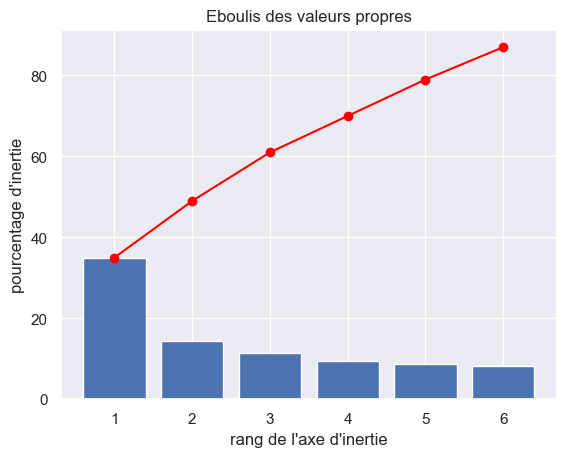

In [64]:
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

L’ébouli des valeurs propres permet de déterminer le nombre de composantes à retenir.
Un compromis est recherché entre la simplification des données et la conservation d’une part significative de l’information totale.

On a en bleu la variance de chaque nouvelle composante, et en rouge la variance cumulée.

On voit ici que près de 61 % de la variance est comprise dans les 3 premières composantes, et près de 70 % dans les 4 premières.

## 3.d Composantes

Intéressons nous maintenant à nos fameuses composantes. C'est par un calcul que l'on obtient ces composantes.

La formule de ce calcul nous est donnée par l'attribut components_. Cette variable est généralement nommée pcs :

In [70]:
pcs = pca.components_
pcs

array([[-0.10152793, -0.18428586,  0.39844622,  0.35744512,  0.44800402,
         0.34866917,  0.23550699,  0.30892235,  0.29630531,  0.2669717 ,
         0.19224807],
       [-0.13383223,  0.03589248,  0.11208042, -0.24518558,  0.18593679,
         0.07791012,  0.49934957, -0.30352943, -0.5671007 , -0.06130802,
         0.44792657],
       [-0.294031  ,  0.64464497, -0.00761468,  0.19178932, -0.12366398,
        -0.2742932 , -0.11828855,  0.38210542,  0.00299436, -0.01784096,
         0.4585673 ],
       [ 0.01933313, -0.40453322, -0.455444  , -0.28026909, -0.20363864,
        -0.23472899,  0.28728568,  0.2685944 ,  0.25783469,  0.32416652,
         0.35664272],
       [ 0.90446671,  0.18237684,  0.16782233,  0.06472764,  0.07660472,
        -0.2108816 ,  0.02646618,  0.02763427, -0.06404351,  0.16260252,
         0.18433682],
       [-0.14929409,  0.1477699 ,  0.01828118, -0.01958681, -0.04296608,
         0.05793477, -0.3035159 , -0.46030336, -0.00595267,  0.80109255,
         0.064

Affichons la même chose mais version `pandas` :

In [72]:
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8,9,10
0,-0.101528,-0.184286,0.398446,0.357445,0.448004,0.348669,0.235507,0.308922,0.296305,0.266972,0.192248
1,-0.133832,0.035892,0.112080,-0.245186,0.185937,0.077910,0.499350,-0.303529,-0.567101,-0.061308,0.447927
2,-0.294031,0.644645,-0.007615,0.191789,-0.123664,-0.274293,-0.118289,0.382105,0.002994,-0.017841,0.458567
3,0.019333,-0.404533,-0.455444,-0.280269,-0.203639,-0.234729,0.287286,0.268594,0.257835,0.324167,0.356643
4,0.904467,0.182377,0.167822,0.064728,0.076605,-0.210882,0.026466,0.027634,-0.064044,0.162603,0.184337
5,-0.149294,0.147770,0.018281,-0.019587,-0.042966,0.057935,-0.303516,-0.460303,-0.005953,0.801093,0.064569


Continuons le travail :

In [74]:
pcs.columns = features
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,dispo_volaille_kcal_jour,production_volaille_per_million,export_volaille_per_million,import_volaille_per_million
F1,-0.10,-0.18,0.40,0.36,0.45,0.35,0.24,0.31,0.30,0.27,0.19
F2,-0.13,0.04,0.11,-0.25,0.19,0.08,0.50,-0.30,-0.57,-0.06,0.45
F3,-0.29,0.64,-0.01,0.19,-0.12,-0.27,-0.12,0.38,0.00,-0.02,0.46
F4,0.02,-0.40,-0.46,-0.28,-0.20,-0.23,0.29,0.27,0.26,0.32,0.36
F5,0.90,0.18,0.17,0.06,0.08,-0.21,0.03,0.03,-0.06,0.16,0.18
F6,-0.15,0.15,0.02,-0.02,-0.04,0.06,-0.30,-0.46,-0.01,0.80,0.06


Nous avons arrondi les résultats pour simplifier l'analyse

Alors, comment calcule t-on la première composante F1 ?

et bien c'est assez simple :

F1 = (-0.10 * pop_2017) + (-0.18 * population_growth_2000_2017_pct) + ... + (0.19 * import_volaille_per_million)

et F2 ?

F2 = (-0.13 * pop_2017) + (0.04 * population_growth_2000_2017_pct) + ... + (0.45 * import_volaille_per_million)

<br>

------------------------

<br>


Dans certains cas, on voudra afficher ce dataframe comme cela :

In [78]:
pcs.T

,F1,F2,F3,F4,F5,F6
pop_2017,-0.101528,-0.133832,-0.294031,0.019333,0.904467,-0.149294
population_growth_2000_2017_pct,-0.184286,0.035892,0.644645,-0.404533,0.182377,0.147770
gdp_per_capita_2017_usd,0.398446,0.112080,-0.007615,-0.455444,0.167822,0.018281
urban_pop_2017_pct,0.357445,-0.245186,0.191789,-0.280269,0.064728,-0.019587
governance_index_mean,0.448004,0.185937,-0.123664,-0.203639,0.076605,-0.042966
trade_freedom_2017,0.348669,0.077910,-0.274293,-0.234729,-0.210882,0.057935
organic_agri_share_pct,0.235507,0.499350,-0.118289,0.287286,0.026466,-0.303516
dispo_volaille_kcal_jour,0.308922,-0.303529,0.382105,0.268594,0.027634,-0.460303
production_volaille_per_million,0.296305,-0.567101,0.002994,0.257835,-0.064044,-0.005953
export_volaille_per_million,0.266972,-0.061308,-0.017841,0.324167,0.162603,0.801093


Et pour une représentation plus *visuelle*, avec un **Heat Map** comme cela :

<Axes: >

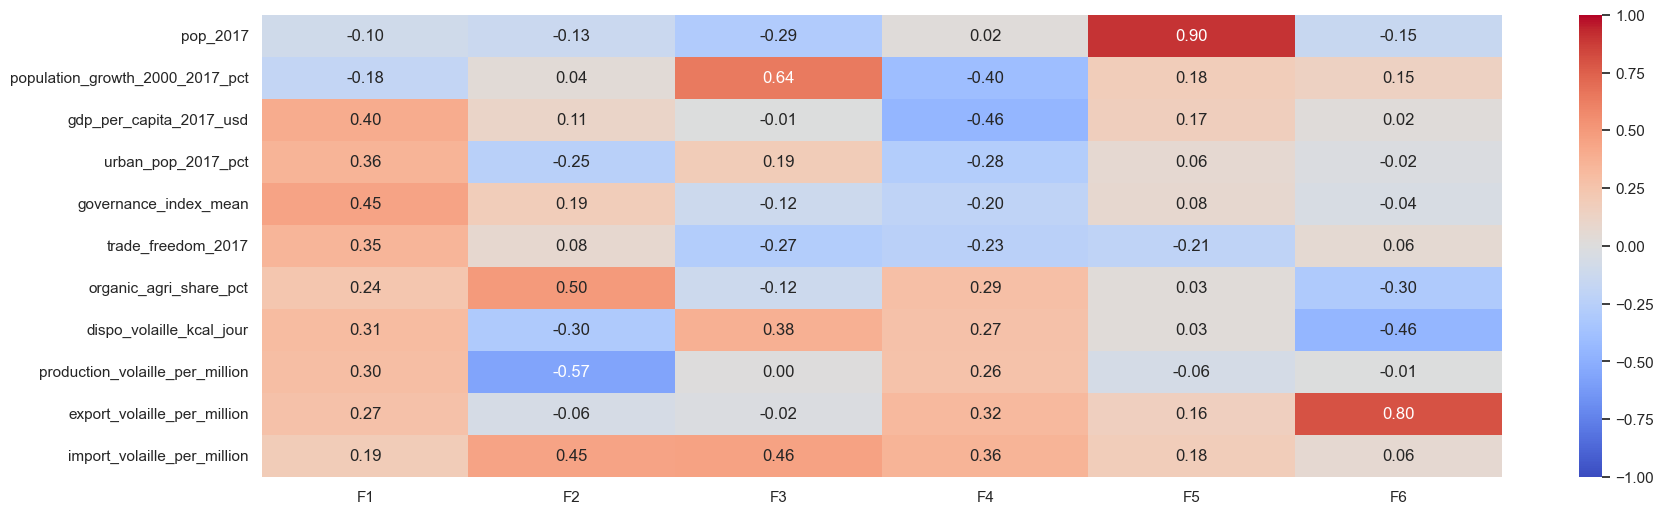

In [80]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

L’analyse des contributions des variables aux composantes principales met en évidence des axes 
économiquement interprétables.

L’axe **F1** apparaît comme un **axe de niveau de développement**, opposant des **pays développés, urbanisés et bien gouvernés** à des **pays moins développés et plus ruraux**.

L’axe **F2** distingue des pays **producteurs de volaille** de **ceux davantage dépendants des importations, en lien avec la structure agricole**.

Les axes **F3** et **F4** apportent des lectures complémentaires, respectivement liées à la **dyamique démographique** et à l’**intensité des échanges commerciaux internaionaux**.

## 3.e Cercles des corrélations

Afin d’interpréter les composantes principales issues de l’ACP, nous analysons les **cercles des corrélations**. 
Ces graphiques permettent de visualiser les relations entre les variables initiales et les axes factoriels, ainsi que la qualité de leur représentation.

La longueur des flèches indique la qualité de représentation des variables sur les axes considérés, tandis que l’angle entre deux flèches renseigne sur le degré de corrélation entre les variables (corrélation positive, négative ou absence de corrélation).


Définissons nos axes x et y. Nous allons utiliser les 2 premières composantes. Comme - en code - on commence à compter à partir de 0, cela nous donne :

In [85]:
x, y = 0,1

Pour la partie graphique :

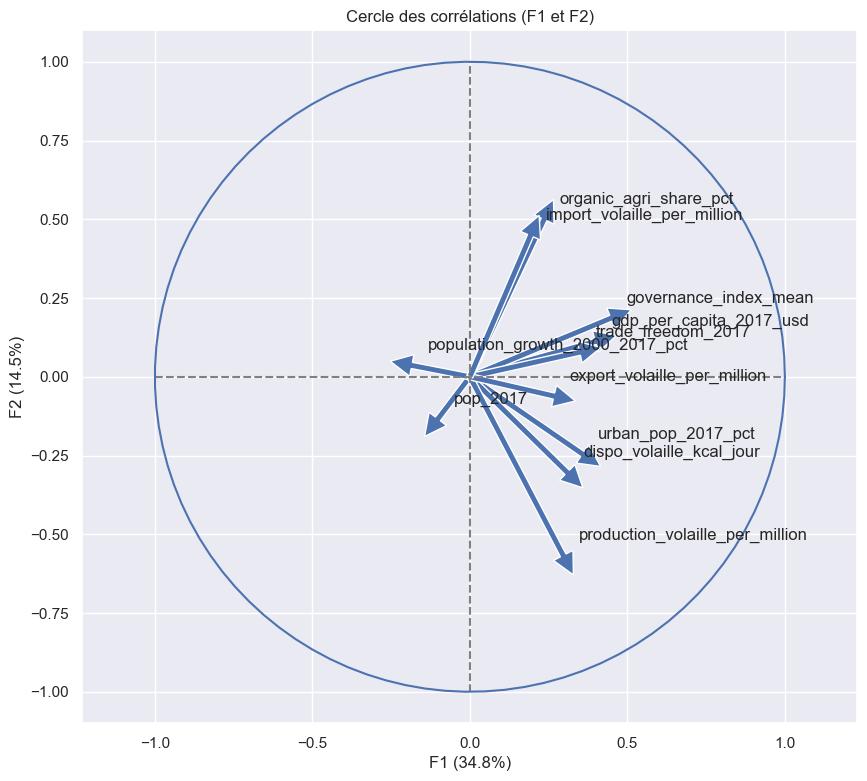

In [87]:
fig, ax = plt.subplots(figsize=(10, 9))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             pca.components_[0, i],  #0 for PC1
             pca.components_[1, i],  #1 for PC2
             head_width=0.07,
             head_length=0.07,
             width=0.02,              )

    plt.text(pca.components_[0, i] + 0.05,
             pca.components_[1, i] + 0.05,
             features[i])

# affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')


# nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale
plt.axis('equal')
plt.show(block=False)

On peut en faire une fonction :

In [89]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

**Essayons cette fonction pour F1 et F2 :**

In [91]:
x_y = (0,1)
x_y

(0, 1)

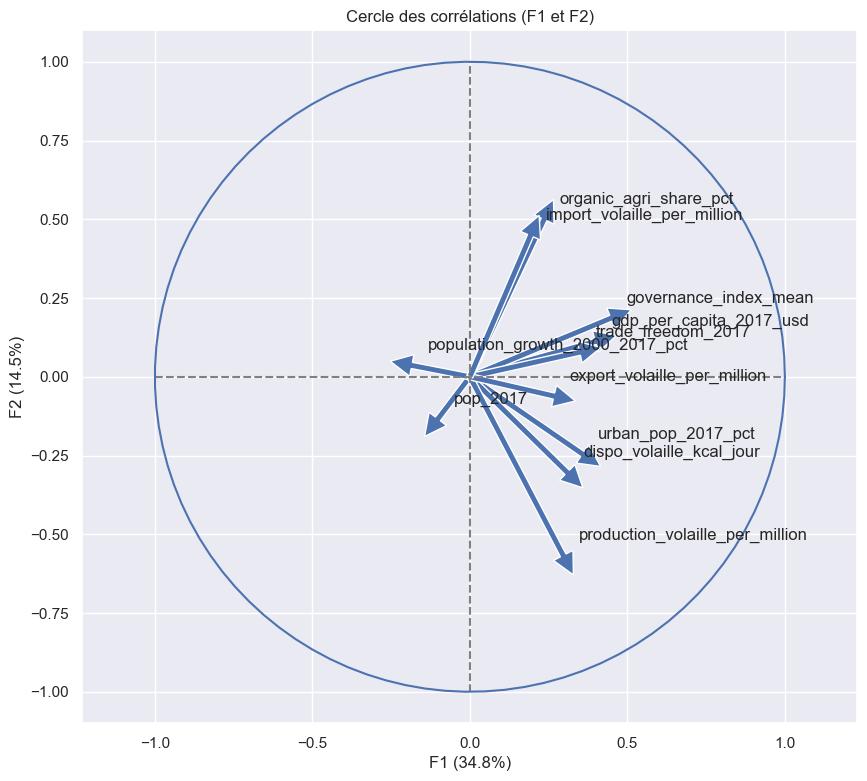

In [92]:
correlation_graph(pca, x_y, features)

Les deux premières composantes principales (F1 et F2) expliquent à elles seules environ 49 % de la variance totale du jeu de données.
Elles constituent donc une synthèse pertinente de l’information initiale.

Le cercle des corrélations F1–F2 met en évidence deux axes fortement interprétables.

L’axe F1 correspond à un axe de niveau de développement et de structuration des marchés 
opposant des pays développés, urbanisés et bien gouvernés à des pays moins développés.
Il est également associé à une plus forte disponibilité alimentaire et à une product on
de volaille intensive par habitant.

L’axe F2 distingue des pays dépendants des importations de volaille et caractéris s par
une part plus élevée d’agriculture biologique, de pays davantage spécialisés  ans la
production de volaille par habitant. Cet axe reflète ainsi des différences de modèles
agricoles et de dépendance commerciale.


**Essayons pour F3 et F4 :**

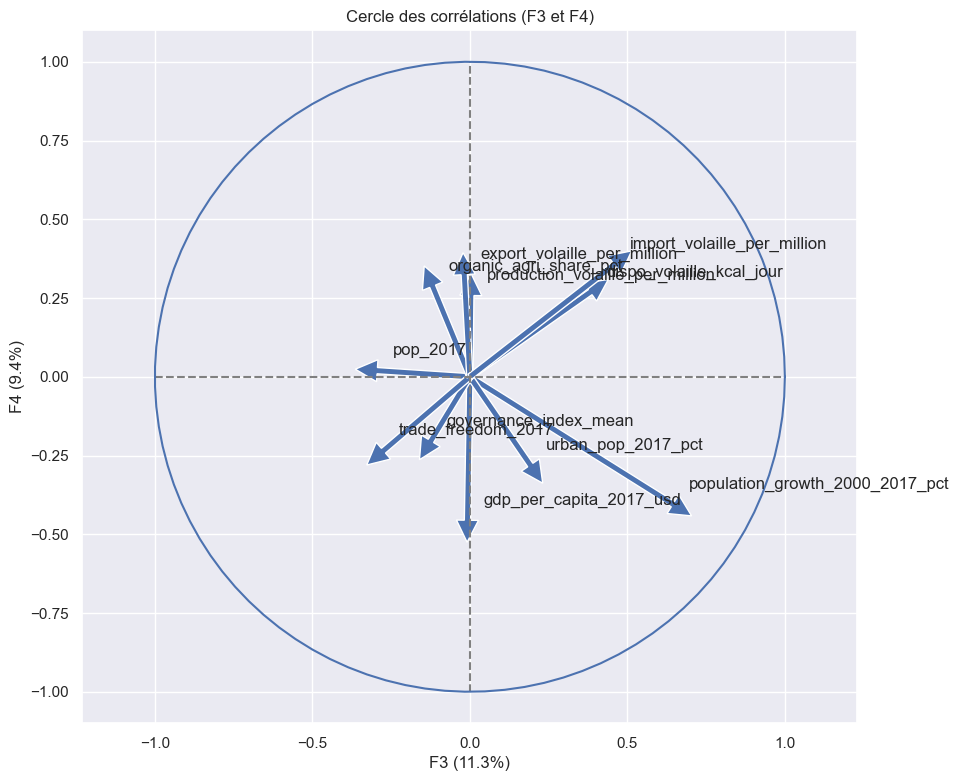

In [95]:
correlation_graph(pca, (2,3), features)

Les composantes F3 et F4 apportent une information complémentaire, représentant environ 21 % supplémentaires de la variance totale. Ces axes mettent en évidence des dimensions plus spécifiques du jeu de données.

L’**axe F3** est principalement lié à la **dynamique démographique** et à la **pression sur la demande alimentaire**, en lien avec le **recours aux importations de volailles**. 

L’**axe F4** met en évidence des logiques de **spécialisation commerciale**, distinguant des **pays fortement intégrés dans les échanges internationaux de volaille**, indépendamment de leur niveau de développement économique.

Toutefois, ces axes présentent une capacité explicative plus limitée et une interprétation moins structura te au regard de l’objectif principal de l’étude. Ils sont donc considérés comme secondaires et ne seront as mobilisés en priorité pour la suite de l’analyse, notamment dans le cadre du clustering.

## 3.f Projection

Travaillons maintenant sur la projection de nos dimensions.

La projection des individus sur les axes factoriels permet de visualiser la position relative des pays dans l’espace réduit par l’ACP. 
Elle met en évidence les proximités et oppositions entre pays, ainsi que les premières structures susceptibles de conduire à des regroupements.


Tout d'abord calculons les coordonnées de nos individus dans le nouvel espace :

In [101]:
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[-0.2894659 ,  0.45989293, -0.59307861,  0.23675333, -0.74630486,
        -0.23142051],
       [ 0.96300982,  1.51396318,  5.81225232, -2.20091008,  1.79013309,
         1.04008162],
       [ 0.75515959, -2.32403768,  1.11464825,  0.90215045,  0.13383398,
        -1.06329267],
       [-0.9966908 ,  0.4273347 , -0.44746278,  0.2488437 , -0.58664596,
         0.01642872],
       [ 3.34047899, -1.00982118,  0.36016144, -0.62858958,  0.02045747,
        -1.55774977]])

Rappelons que :

In [103]:
x_y

(0, 1)

voici la fonction :

In [105]:
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()


Essayons la version *simple* avec F1 et F2, les couleurs correspondent au niveau  :

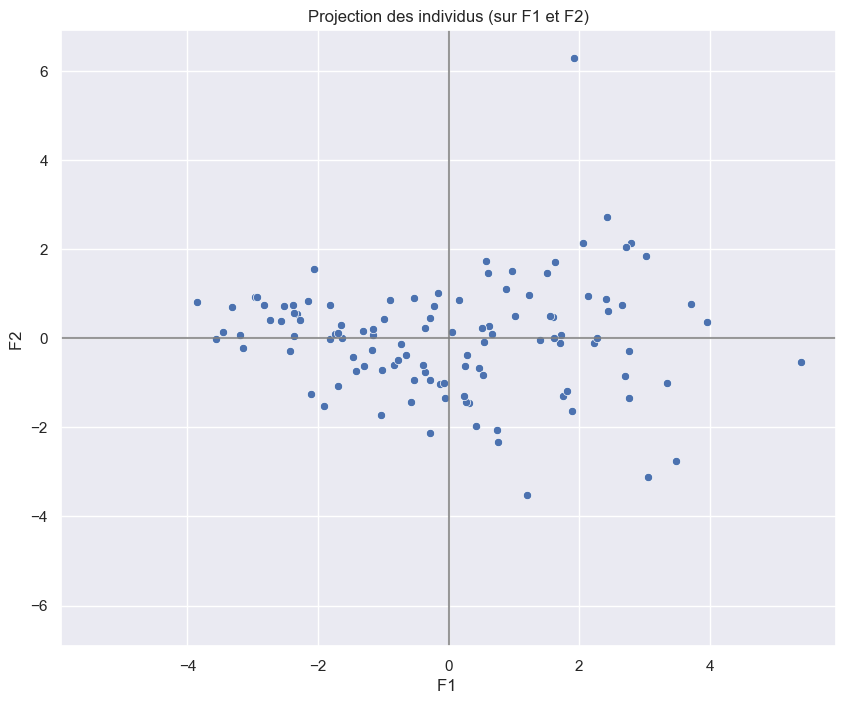

In [107]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y)

La projection des pays sur le plan F1–F2 met en évidence une structuration progressive de l’espace factoriel.

La majorité des pays se concentre autour de l’origine, traduisant des profils intermédiaires tandis que certains pays s’éloignent du centre et présentent des caractéristiques plus spécifiques.

L’axe **F1** apparaît comme le **principal axe de différenciation des pays**, opposant des **pays développés, urbanisés et bien gouvernés** à des **pays moins développés et plus ruraux**.

L’axe **F2** apporte une lecture complémentaire en distinguant des **pays dépendants des importations de volaille** de **ceux davantage spécialisés dans la production de volaille par habitant**.

Cette organisation suggère l’**existence de groupes de pays présentant des caractéristiques proches**, ce qui justifie la mise en œuvre d’une **analyse de clustering** afin d’**identifier des profils homogènes**.


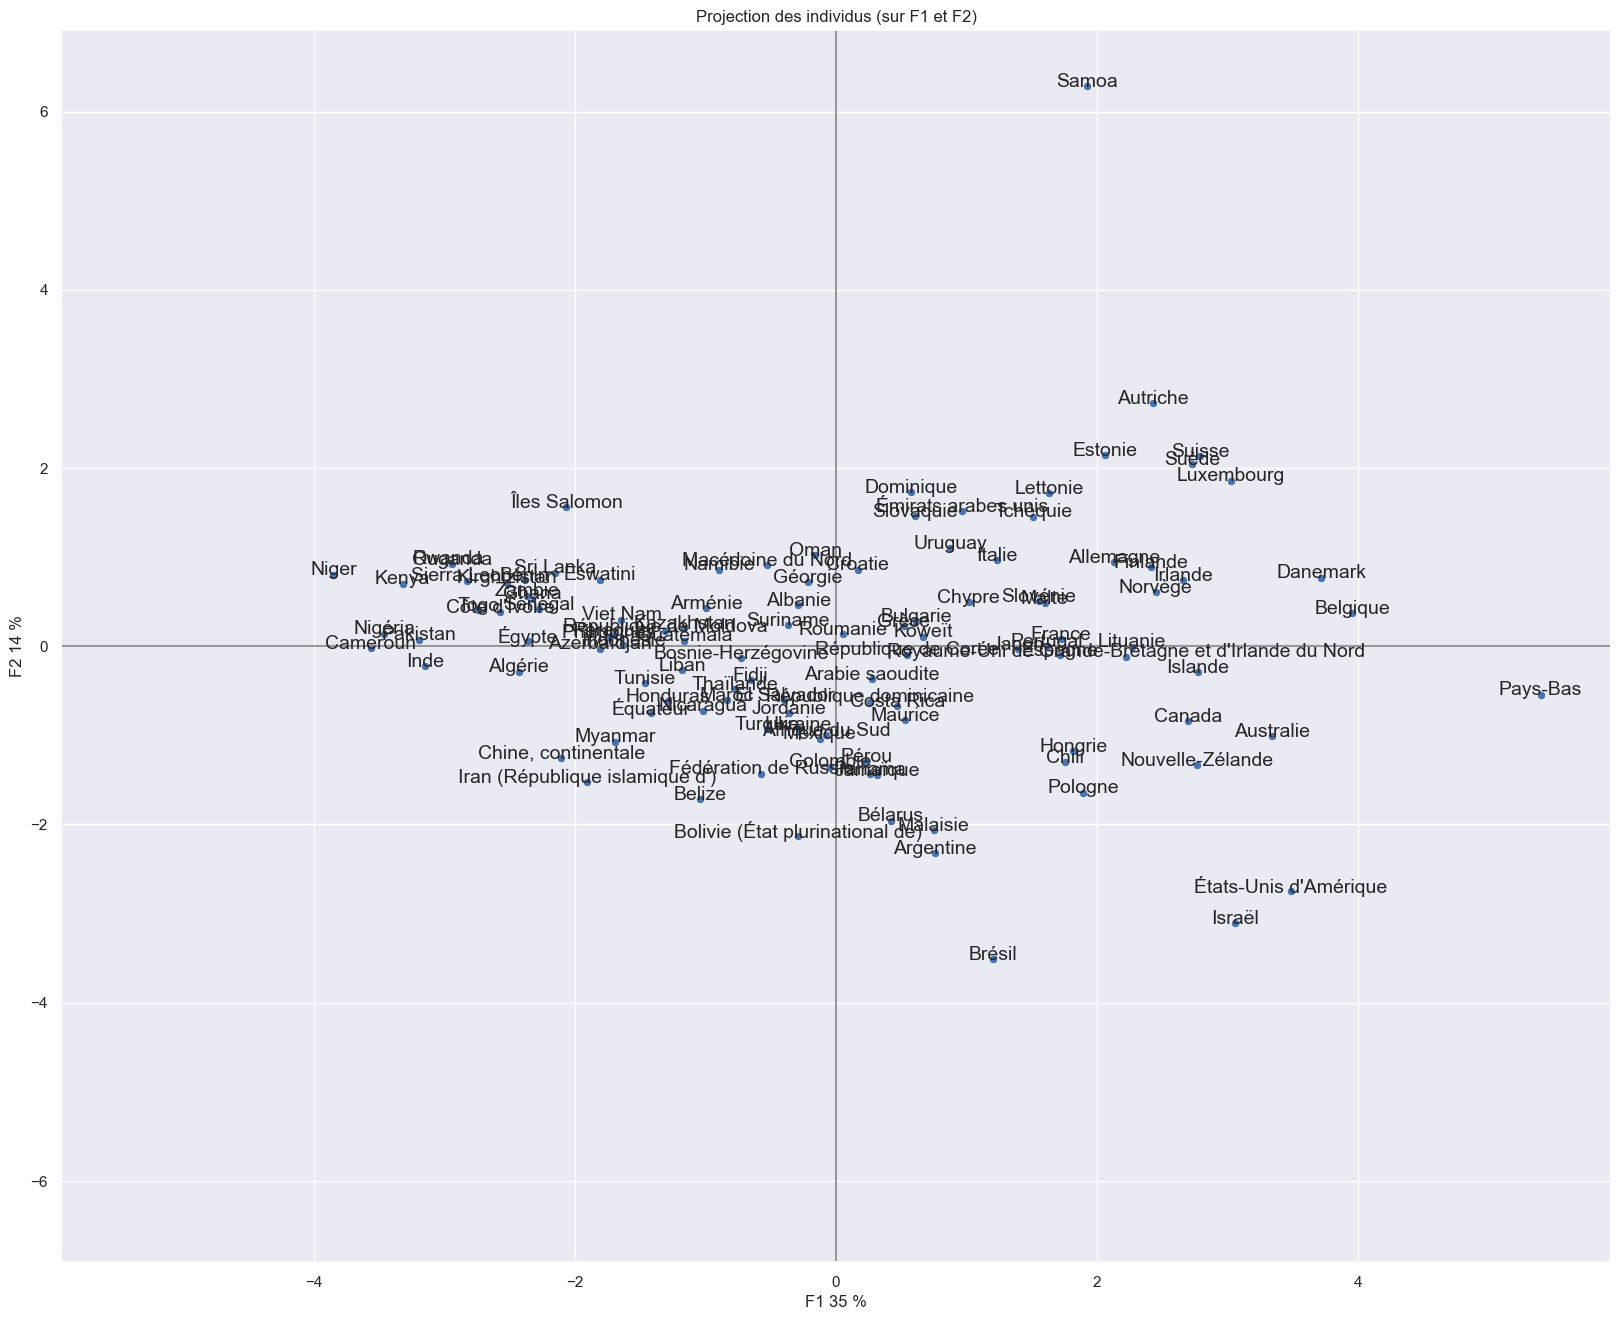

In [109]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, labels=names, figsize=(20,16))

La projection des pays sur le plan **F1–F2**, enrichie par l’affichage des noms des pays, confirme l’interprétation des axes issue du cercle des corrélations.

**L’axe F1** distingue clairement les **pays développés, urbanisés et bien gouvernés** (tels que les **Pays-Bas**, la **Belgique**, la **Suisse** ou le **Danemark**)
des **pays moins développés et plus ruraux** (comme le **Niger**, **l’Éthiopie** ou le **Bangladesh**).
Cet axe apparaît comme le **principal facteur de différenciation** entre les pays.

**L’axe F2** met en évidence des **différences de modèles agricoles et commerciaux.** Les pays situés **en partie haute du graphique** apparaissent **davantage dépendants des importations de volaille**, à l’image de **l'Autriche**, du **Luxembourg** ou de **Samoa**, tandis que ceux situés **en partie basse** se distinguent par une **production de volaille plus intensive par habitant**, comme le **Brésil**, les **États-Unis** ou **l’Argentine**.

Enfin, **certains pays présentent des profils atypiques**, illustrant des situations spécifiques de **dépendance alimentaire** (C’est notamment le cas de **Samoa**, dont la position très élevée sur l’axe F2 traduit une forte dépendance aux importations de volaille, liée à son isolement géographique)
ou de **spécialisation productive** comme le **Brésil** ou les **États-Unis** (visible par leur position en partie basse du graphique). 

Cette structuration de l’espace factoriel met ainsi en évidence **l’existence de profils de pays différenciés**, ce qui **justifie pleinement la mise en œuvre d’une analyse de clustering** afin d’identifier des groupes homogènes.


# 4) Clustering des pays (sur les composantes de l’ACP)

## 4.a Objectif et données utilisées pour le clustering

Nous réalisons maintenant un clustering afin de regrouper les pays présentant des profils similaires.
Pour cela, nous utilisons les **scores des pays sur les composantes principales** issues de l’ACP (variables non corrélées), ce qui permet de réduire la dimension tout en conservant l’essentiel de l’information.
Ces regroupements permettront de caractériser différents profils de pays et d’orienter les recommandations stratégiques.


## 4.b Préparer la matrice X_clust

In [115]:
# Nombre d'axes retenus pour le clustering (ici F1 à F4)
n_comp_clust = 4

X_clust = X_proj[:, :n_comp_clust]

# DataFrame pratique pour l'interprétation (index = pays)
scores_df = pd.DataFrame(
    X_clust,
    columns=[f"F{i}" for i in range(1, n_comp_clust+1)],
    index=df.index
)

scores_df.head()


,F1,F2,F3,F4
country,,,,
Albanie,-0.289466,0.459893,-0.593079,0.236753
Émirats arabes unis,0.963010,1.513963,5.812252,-2.200910
Argentine,0.755160,-2.324038,1.114648,0.902150
Arménie,-0.996691,0.427335,-0.447463,0.248844
Australie,3.340479,-1.009821,0.360161,-0.628590


## 4.c CAH (Classification Ascendante Hiérarchique)

### *4.c.1 - Imports*

In [118]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

### *4.c.2 - Calcul de la CAH + dendrogramme*

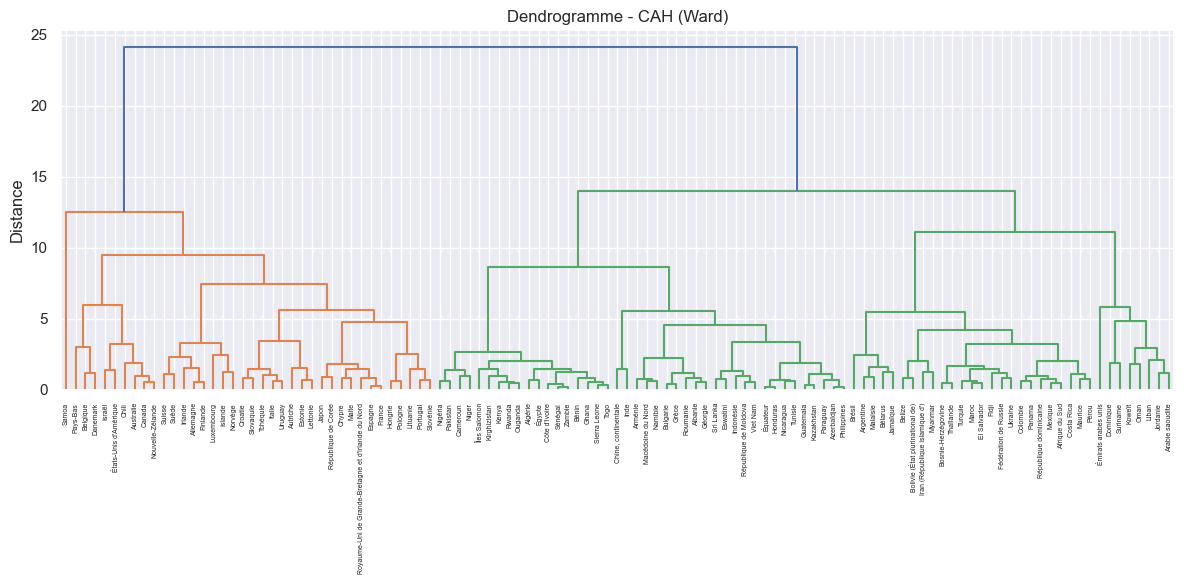

In [120]:
Z = linkage(X_clust, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=scores_df.index, leaf_rotation=90)
plt.title("Dendrogramme - CAH (Ward)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


La **CAH** (**méthode de Ward**) permet d’explorer la **structure hiérarchique des pays**.

Le **dendrogramme** issu de la classification ascendante hiérarchique (méthode de Ward) met en évidence une structuration claire des pays ; il permet de suggérer un nombre raisonnable de classes en observant les ruptures de distance.

On observe une **rupture nette** dans les **distances de fusion** autour d’une **hauteur comprise entre 13 et 15**, suivie d’un **saut beaucoup plus important vers 25**.

Cette **rupture** suggère **l’existence de plusieurs groupes de pays bien distincts**.

Une coupe du dendrogramme à ce niveau conduit naturellement à retenir **quatre clusters**, offrant un bon compromis entre lisibilité des résultats
et richesse de l’interprétation.

### *4.c.3 - Choisir un nombre de clusters (k) et créer les labels CAH*

#### **Diagramme du coude**

Afin de compléter l’analyse issue du dendrogramme, un **diagramme du coude** est utilisé.
    
Il permet d’**observer l’évolution de l’inertie intra-cluster en fonction du nombre de clusters** et d’**identifier un point à partir duquel l’ajout de clusters n’apporte plus de gain significatif**.


C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

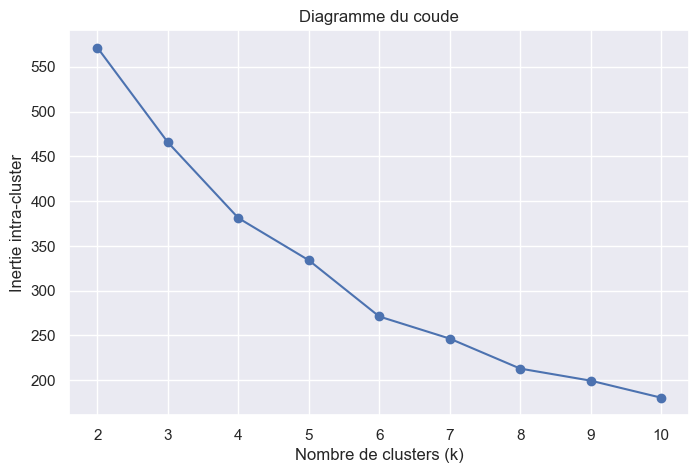

In [126]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_proj[:, :4])  # ACP sur les 4 premières composantes
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie intra-cluster")
plt.title("Diagramme du coude")
plt.show()


Le diagramme du coude met en évidence une diminution rapide de l’inertie intra-cluster jusqu’à **k = 4**, puis une baisse plus progressive au-delà.
Ce point de rupture suggère que l’ajout de clusters supplémentaires n’apporte qu’un gain marginal en termes de compacité des groupes.


#### **Coefficient de silhouette**


Le **coefficient de silhouette** permet d’**évaluer la qualité de la partition obtenue**, en mesurant à quel point chaque observation est bien assignée à son cluster
par rapport aux autres clusters.
Sa **valeur** est **comprise entre -1 et 1**, une valeur élevée indiquant une bonne séparation.


C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

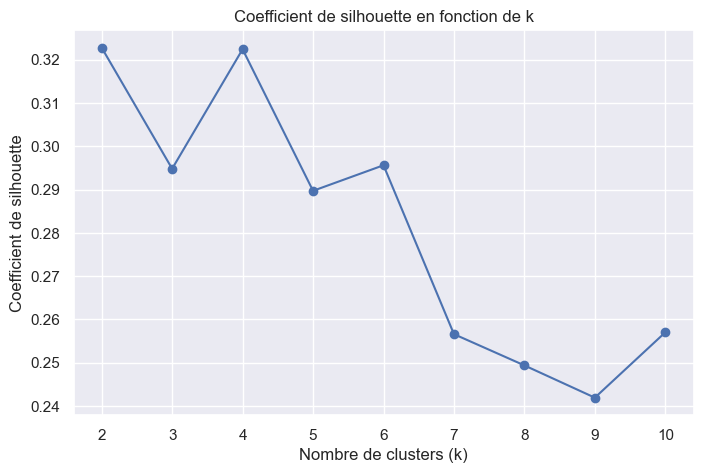

In [130]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_proj[:, :4])
    score = silhouette_score(X_proj[:, :4], labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Coefficient de silhouette")
plt.title("Coefficient de silhouette en fonction de k")
plt.show()


L’analyse du coefficient de silhouette apporte un éclairage quantitatif complémentaire au choix du nombre de clusters.
La valeur du coefficient atteint un **maximum pour k = 4 (≈ 0,32)**, indiquant une **bonne séparation entre les groupes** et une **cohérence interne satisfaisante** des clusters.

Une valeur légèrement élevée est également observée pour **k = 2**, mais ce nombre de clusters apparaît **trop grossier d’un point de vue analytique et métier**, car il regroupe des pays aux profils économiques et agricoles très différents.

À l’inverse, à partir de **k ≥ 6**, le coefficient de silhouette diminue nettement (autour de **0,25** ou moins), traduisant une **dégradation de la qualité de la partition** et une séparation moins nette entre les groupes.

Dans le contexte de données multivariées hétérogènes portant sur des pays, une valeur de coefficient de silhouette proche de **0,3** est considérée comme **tout à fait satisfaisante**.

Le choix de **k = 4** apparaît ainsi comme le **meilleur compromis** entre **qualité de séparation**, **granularité des clusters** et **interprétabilité économique**.


#### **Choix porté sur 4 clusters**

La combinaison des résultats issus du **dendrogramme**, du **diagramme du coude** et du **coefficient de silhouette** converge vers le choix de **quatre clusters**.
Ce nombre de groupes offre un bon compromis entre qualité de segmentation, lisibilité des résultats et interprétation économique.


In [134]:
k_cah = 4 

labels_cah = fcluster(Z, t=k_cah, criterion="maxclust")

df["cluster_cah"] = labels_cah
df["cluster_cah"].value_counts().sort_index()


cluster_cah
1    37
2     1
3    42
4    33
Name: count, dtype: int64

L’application de la classification ascendante hiérarchique avec **k = 4** conduit à la formation de **trois clusters de tailles comparables** et d’**un cluster de taille réduite, composé d’un seul pays**.

Ce résultat traduit l’existence d’un **profil très atypique**, fortement éloigné des autres pays sur les variables analysées.
    
La CAH, et en particulier la méthode de Ward, est sensible à ce type de situation et peut isoler des observations extrêmes dans un cluster spécifique.

Ce cluster unitaire ne constitue pas une anomalie, mais met en évidence un cas particulier, qui sera intéressant à comparer avec les résultats obtenus via l’algorithme k-means, moins sensible aux observations isolées.


### *4.c.4 - Projection des clusters CAH sur F1–F2*

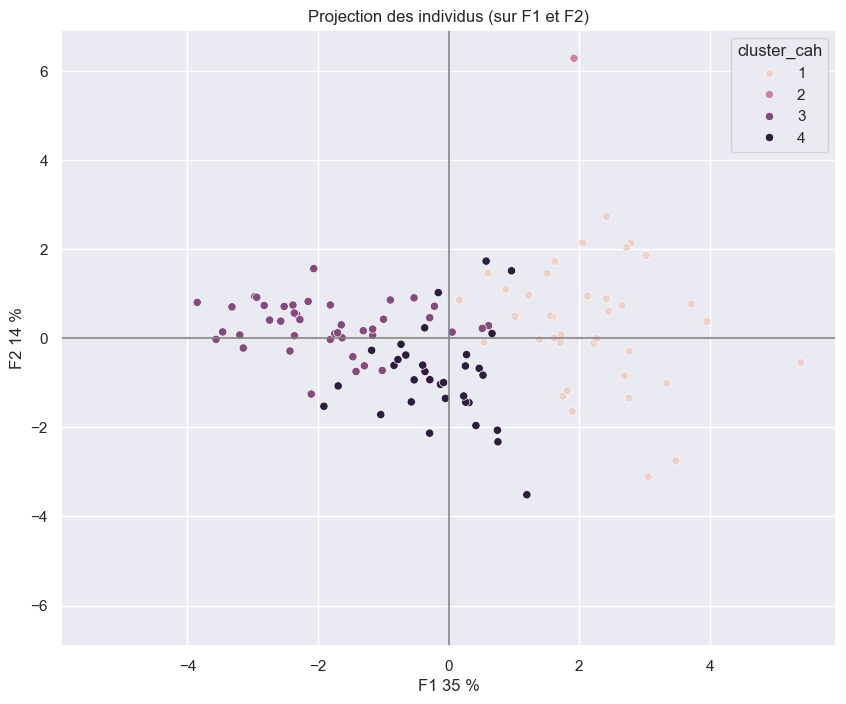

In [137]:
display_factorial_planes(
    X_proj,
    [0, 1],
    pca=pca,
    clusters=df["cluster_cah"],
    alpha=0.8,
    figsize=[10, 8]
)


In [138]:
# Pays isolé (cluster de taille 1)
isolated = df.loc[df["cluster_cah"] == 2].index.tolist()
isolated


['Samoa']

La projection des clusters issus de la classification ascendante hiérarchique sur le plan F1–F2 met en évidence une structuration claire de l’espace factoriel.

Les groupes de pays sont principalement différenciés selon l’axe F1, qui reflète le niveau de développement et de structuration des marchés.

Un premier cluster (**cluster n° 1**) regroupe des **pays développés, urbanisés et bien gouvernés**, situés majoritairement **à droite du plan factoriel**.

**À l’opposé**, un second cluster (**cluster n° 3**) rassemble des **pays moins développés, plus ruraux et caractérisés par des marchés alimentaires moins structurés**.

Un troisième cluster (**cluster n° 4**) occupe une position intermédiaire, correspondant à des **profils de pays mixtes ou en transition**.

Enfin, la **CAH isole un pays au profil très atypique** (à savoir les **Samoa**) dans un **cluster spécifique** (**cluster n° 2**), traduisant une **situation particulière de dépendance ou de spécialisation**.

Cette configuration illustre la capacité de la CAH à mettre en évidence des observations extrêmes, et sera comparée aux résultats obtenus avec l’algorithme **k-means**.

## 4.d K-means

Après la CAH, nous appliquons l’algorithme des k-means afin d’obtenir une partition des pays en un nombre fixé de groupes.
Contrairement à la CAH (approche hiérarchique), le k-means cherche à minimiser la variabilité à l’intérieur de chaque cluster
en regroupant les pays autour de centroïdes (centres de clusters) dans l’espace des composantes principales.

Dans la continuité de l’analyse précédente, nous conservons le même nombre de clusters (k = 4) afin de comparer directement
les résultats du k-means avec ceux de la CAH. Le clustering est réalisé à partir des scores ACP retenus (F1 à F4), ce qui
permet de travailler sur des variables standardisées et non corrélées.


### *4.d.1 - lancement du k-means*

In [143]:
from sklearn.cluster import KMeans

k_kmeans = 4

kmeans = KMeans(n_clusters=k_kmeans, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_clust)

df["cluster_kmeans"] = labels_kmeans + 1  # labels 1..k pour lecture plus simple
df["cluster_kmeans"].value_counts().sort_index()


C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


cluster_kmeans
1    48
2     7
3    34
4    24
Name: count, dtype: int64

L’application de l’algorithme k-means avec **k = 4** conduit à une **répartition des pays** en **quatre clusters de tailles plus équilibrées** que celles obtenues par la classification ascendante hiérarchique.

Contrairement à la CAH, **aucun cluster n’est composé d’un seul pays**. Le k-means assigne systématiquement chaque observation à un cluster, ce qui le rend moins sensible aux observations atypiques.

Ainsi, des **pays présentant des profils spécifiques** sont **intégrés au cluster le plus proche** en termes de **distance aux centroïdes**.

Cette partition offre une **segmentation plus opérationnelle**, tout **en restant cohérente avec la structure révélée par l’ACP**.


### *4.d.2 - Projection des clusters k-means sur le plan F1–F2*

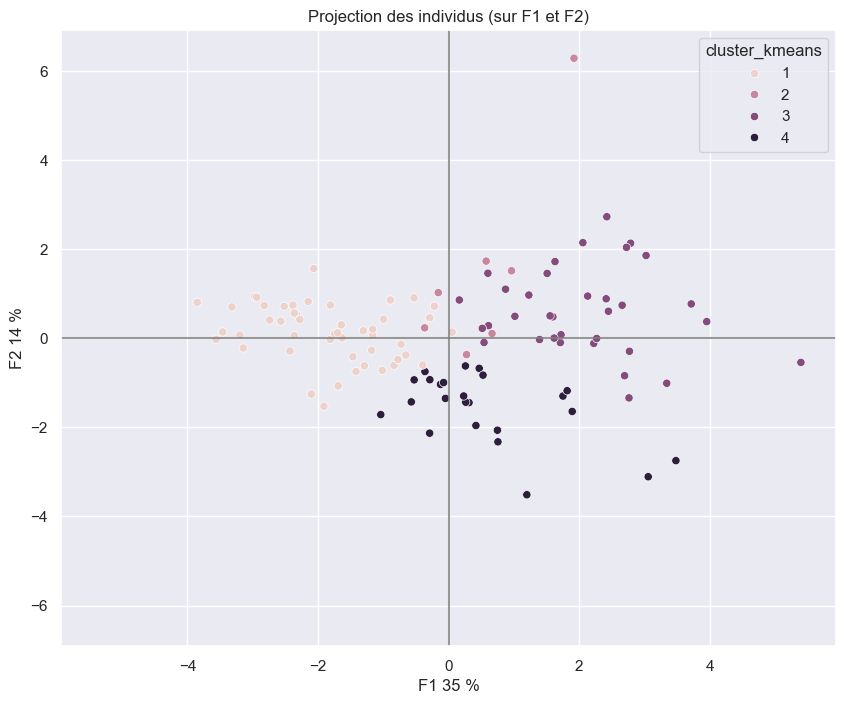

In [146]:
display_factorial_planes(
    X_proj,
    [0, 1],
    pca=pca,
    clusters=df["cluster_kmeans"],
    alpha=0.8,
    figsize=[10, 8]
)


La projection des clusters issus de l’algorithme k-means sur le plan F1–F2 met en évidence une structuration cohérente et lisible de l’espace factoriel.

Les groupes sont principalement différenciés selon l’axe F1, qui reflète le niveau de développement et de structuration des marchés, et de manière complémentaire selon l’axe F2, lié aux modèles agricoles et à la dépendance commerciale.

Le **cluster 1** (couleur claire), situé majoritairement à gauche du plan (F1 négatif), regroupe des pays **moins développés**, plus ruraux, caractérisés par des niveaux de revenu et de gouvernance plus faibles. Ces pays présentent généralement une production de volaille limitée et des marchés alimentaires moins structurés.

Le **cluster 3** (couleur violette), positionné à droite du plan avec des valeurs positives sur F2, correspond à des pays **développés mais davantage dépendants des importations de volaille**. Ces pays disposent d’un cadre institutionnel solide et d’un niveau de vie élevé, mais d’une production nationale de volaille plus limitée, ce qui les rend plus dépendants des échanges internationaux.

Le **cluster 4** (couleur foncée), également situé à droite du plan mais avec des valeurs négatives sur F2, regroupe des pays **plus spécialisés dans la production de volaille par habitant**. Il s’agit de pays producteurs intensifs, souvent bien intégrés aux marchés internationaux, combinant capacité productive et structuration économique.

Enfin, le **cluster 2** (couleur intermédiaire), de taille plus réduite et proche du centre du plan factoriel, rassemble des pays aux **profils intermédiaires ou spécifiques**. Ces pays ne se distinguent pas de manière aussi marquée que les autres groupes, et peuvent être interprétés comme des profils de transition ou des cas particuliers, intégrés par le k-means au cluster le plus proche en termes de distance aux centroïdes.


## 4.e Comparaison CAH vs k-means

Deux méthodes de clustering ont été mises en œuvre afin de segmenter les pays : la **classification ascendante hiérarchique (CAH)** et l’algorithme **k-means**.

L’objectif est de comparer les résultats obtenus et d’évaluer la stabilité et la pertinence des clusters identifiés.


| Critère | CAH (Ward) | k-means |
|-------|-----------|---------|
| Principe | Méthode hiérarchique | Méthode itérative par centroïdes |
| Nombre de clusters | 4 | 4 |
| Taille des clusters | Déséquilibrée (1 cluster unitaire) | Plus équilibrée |
| Sensibilité aux profils atypiques | Élevée | Plus faible |
| Lisibilité métier | Bonne | Très bonne |
| Usage privilégié | Exploration | Segmentation opérationnelle |


La **CAH** met en évidence la **structure hiérarchique des données** et permet d’**identifier des profils très atypiques**, comme un pays isolé dans un cluster spécifique. En revanche, cette méthode peut conduire à des clusters très déséquilibrés en taille.

À l’inverse, le **k-means** produit des **clusters plus homogènes et mieux équilibrés**, en intégrant les observations atypiques dans le groupe le plus proche. Cette **approche** apparaît ainsi **plus adaptée à une segmentation opérationnelle** dans une optique de recommandation stratégique.

**Au regard de ces éléments, les résultats du k-means sont retenus pour la suite 
de l’analyse**, tout en s’appuyant sur la CAH comme outil exploratoire complémentaire



## 4.f Choix du cluster cible + liste des pays

Dans une perspective de développement international pour *La poule qui chante*,
le cluster ciblé doit idéalement présenter :

- **un niveau de développement économique suffisant** (PIB/habitant),
- **un marché structuré** (urbanisation),
- **un environnement institutionnel favorable** (gouvernance, liberté économique),
- **un potentiel de débouché** pour la volaille (dépendance aux importations),
- et, si possible, un **signal favorable au bio** (part de l’agriculture biologique).

Nous comparons donc les clusters **k-means** sur un ensemble de variables clés afin
d’identifier le cluster le plus pertinent.

In [154]:
key_vars = [
    "gdp_per_capita_2017_usd",
    "governance_index_mean",
    "trade_freedom_2017",
    "import_volaille_per_million",
    "organic_agri_share_pct",
    "urban_pop_2017_pct",
    "production_volaille_per_million",
    "dispo_volaille_kcal_jour"
]

summary = df.groupby("cluster_kmeans")[key_vars].mean().round(2)
summary


,gdp_per_capita_2017_usd,governance_index_mean,trade_freedom_2017,import_volaille_per_million,organic_agri_share_pct,urban_pop_2017_pct,production_volaille_per_million,dispo_volaille_kcal_jour
cluster_kmeans,,,,,,,,
1,3626.51,-0.42,75.60,3.28,0.73,48.52,9.79,42.50
2,18817.05,0.19,76.76,43.25,5.68,72.59,8.07,143.71
3,40070.92,1.16,86.35,10.94,7.94,77.80,24.61,84.00
4,12641.20,0.05,80.48,3.19,1.12,73.94,43.62,130.54


In [155]:
summary_style = (
    summary
    .style
    .background_gradient(
        cmap="Blues",        # palette lisible et sobre
        axis=0               # gradient par colonne (le plus pertinent ici)
    )
    .format("{:.2f}")        # format homogène
)

summary_style


,gdp_per_capita_2017_usd,governance_index_mean,trade_freedom_2017,import_volaille_per_million,organic_agri_share_pct,urban_pop_2017_pct,production_volaille_per_million,dispo_volaille_kcal_jour
cluster_kmeans,,,,,,,,
1,3626.51,-0.42,75.60,3.28,0.73,48.52,9.79,42.50
2,18817.05,0.19,76.76,43.25,5.68,72.59,8.07,143.71
3,40070.92,1.16,86.35,10.94,7.94,77.80,24.61,84.00
4,12641.20,0.05,80.48,3.19,1.12,73.94,43.62,130.54


Regardons maintenant avec un heatmap : 

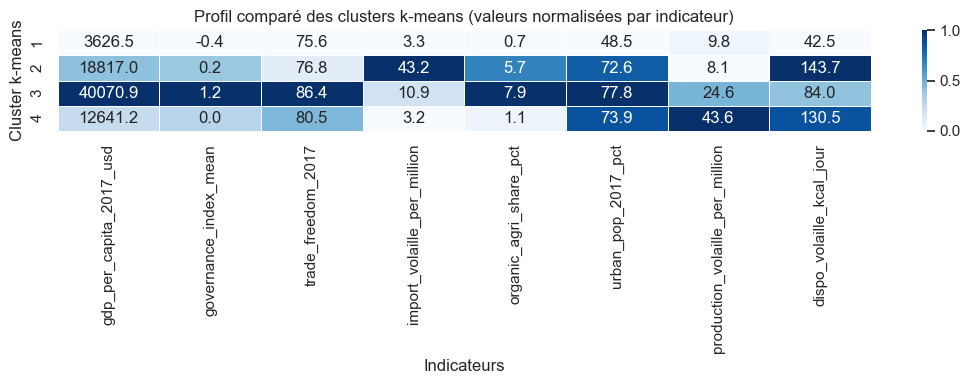

In [157]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Normalisation colonne par colonne (0–1)
scaler = MinMaxScaler()
summary_scaled = pd.DataFrame(
    scaler.fit_transform(summary),
    columns=summary.columns,
    index=summary.index
)

# Heatmap normalisée
plt.figure(figsize=(11, 4))
sns.heatmap(
    summary_scaled,
    annot=summary.round(1),   # on garde les vraies valeurs visibles
    fmt="",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Profil comparé des clusters k-means (valeurs normalisées par indicateur)")
plt.ylabel("Cluster k-means")
plt.xlabel("Indicateurs")
plt.tight_layout()
plt.show()



Lecture du tableau et du heatmap :

- Le **cluster 2** se distingue par une **dépendance très forte aux importations de volaille**
(import_volaille_per_million = **43.25**), tout en présentant un niveau de vie correct
(PIB/hab ≈ **18,817 $**) et un marché relativement structuré (urbanisation ≈ **72.6%**).

- Le **cluster 3** correspond à des pays très développés (PIB/hab ≈ **40,071 $**),
avec une gouvernance élevée, mais une dépendance aux importations plus limitée
(import_volaille_per_million ≈ **10.94**).

- Le **cluster 4** est davantage orienté “production” (production_volaille_per_million ≈ **43.62**),
ce qui peut réduire l’intérêt en tant que marché cible pour une stratégie orientée débouchés.

Au regard des critères de marché (solvabilité + structure + dépendance aux importations),
le **cluster 2** apparaît comme le plus pertinent pour la suite.


In [159]:
cluster_target = 2  # choix recommandé au vu du tableau de synthèse


In [160]:
cluster_target = 2  # ton cluster cible

countries_target = (
    df.loc[df["cluster_kmeans"] == cluster_target]
      .index
      .sort_values()
      .tolist()
)

len(countries_target), countries_target[:20]


(7,
 ['Arabie saoudite',
  'Dominique',
  'Koweït',
  'Oman',
  'Samoa',
  'Suriname',
  'Émirats arabes unis'])

In [161]:
pd.Series(countries_target, name=f"Pays du cluster cible (k-means {cluster_target})")


0        Arabie saoudite
1              Dominique
2                 Koweït
3                   Oman
4                  Samoa
5               Suriname
6    Émirats arabes unis
Name: Pays du cluster cible (k-means 2), dtype: object

In [162]:
top_importers = (
    df.loc[df["cluster_kmeans"] == cluster_target, ["import_volaille_per_million"]]
      .sort_values("import_volaille_per_million", ascending=False)
)

top_importers


,import_volaille_per_million
country,
Samoa,87.022401
Dominique,55.976938
Émirats arabes unis,45.640427
Koweït,33.776296
Suriname,31.551492
Oman,27.004274
Arabie saoudite,21.811912


In [163]:
df.loc[df["cluster_kmeans"] == cluster_target,
       ["import_volaille_per_million", "production_volaille_per_million", "dispo_volaille_kcal_jour"]
      ].describe().round(2)


,import_volaille_per_million,production_volaille_per_million,dispo_volaille_kcal_jour
count,7.00,7.00,7.00
mean,43.25,8.07,143.71
std,22.49,8.33,44.03
min,21.81,0.00,73.00
25%,29.28,0.75,129.50
50%,33.78,5.06,150.00
75%,50.81,15.67,153.50
max,87.02,18.61,217.00


Sur la base du profil moyen des clusters, le **cluster 2 (k-means)** est retenu
comme **cluster cible prioritaire**. Il combine :
- une **forte dépendance aux importations de volaille** (potentiel de débouché),
- un **niveau de développement économique suffisant**,
- un marché relativement **urbanisé et structuré**,
- et un signal favorable pour le **bio**.

La liste des pays appartenant à ce cluster est extraite ci-dessus afin d’identifier
les pays à prioriser pour une première phase d’expansion.


**Choix des pays prioritaires :**

Afin d’affiner le choix des pays prioritaires au sein du cluster cible,
un tableau décisionnel est construit à partir des principaux indicateurs économiques,
institutionnels et agroalimentaires.

La mise en forme en dégradé de couleurs permet une lecture comparative par indicateur,
facilitant l’identification des pays combinant niveau de développement,
dépendance aux importations de volaille et potentiel de marché.

In [167]:
# ========================================
# 4.f – Choix du cluster cible (k-means)
#       Tableau décisionnel par pays
# ========================================

# Cluster cible retenu
cluster_target = 2

# Indicateurs clés pour la décision
decision_vars = [
    "gdp_per_capita_2017_usd",
    "governance_index_mean",
    "trade_freedom_2017",
    "urban_pop_2017_pct",
    "import_volaille_per_million",
    "production_volaille_per_million",
    "organic_agri_share_pct",
    "dispo_volaille_kcal_jour"
]

# Tableau de décision
decision_table = (
    df.loc[df["cluster_kmeans"] == cluster_target, decision_vars]
      .round(2)
      .sort_values("import_volaille_per_million", ascending=False)
)

# Tableau stylé (heatmap par indicateur)
decision_style = (
    decision_table.style
    .background_gradient(cmap="Blues", axis=0)
    .format("{:.2f}")
)

decision_style



,gdp_per_capita_2017_usd,governance_index_mean,trade_freedom_2017,urban_pop_2017_pct,import_volaille_per_million,production_volaille_per_million,organic_agri_share_pct,dispo_volaille_kcal_jour
country,,,,,,,,
Samoa,4307.59,0.69,70.70,18.45,87.02,0.00,37.60,217.00
Dominique,8224.65,0.54,72.60,70.18,55.98,0.00,0.96,150.00
Émirats arabes unis,42340.59,0.63,83.50,86.25,45.64,5.06,1.10,147.00
Koweït,29047.65,-0.21,78.70,100.00,33.78,13.81,0.01,156.00
Suriname,6049.52,-0.17,68.40,66.04,31.55,17.53,0.07,112.00
Oman,17820.07,0.14,85.20,83.56,27.00,1.50,0.00,73.00
Arabie saoudite,23929.29,-0.29,78.20,83.62,21.81,18.61,0.01,151.00


L’analyse détaillée des indicateurs par pays au sein du cluster cible permet d’affiner la priorisation des marchés à fort potentiel pour La poule qui chante.

🔹 Les **Émirats arabes unis** apparaissent comme le pays prioritaire.
Ils combinent une forte dépendance aux importations de volaille
(import_volaille_per_million ≈ 45,6), un niveau de vie très élevé
(PIB par habitant ≈ 42 300 $), une urbanisation très importante
(≈ 86 %) et une production locale limitée.
Ce profil traduit un besoin structurel d’approvisionnement extérieur,
particulièrement favorable à des produits à forte valeur ajoutée comme la volaille biologique.

🔹 Le **Koweït** constitue une seconde priorité crédible.
Le pays présente une dépendance significative aux importations
(≈ 33,8), un pouvoir d’achat élevé, un marché entièrement urbanisé
(100 %) et une production locale présente mais insuffisante pour couvrir la demande,
ce qui en fait un marché attractif pour des produits différenciants.

🔹 L’**Arabie saoudite** offre un potentiel de volume important, porté par la taille de son marché et son niveau de développement économique.
Toutefois, la production locale plus significative et la complexité du marché suggèrent une approche plus progressive, éventuellement dans un second temps.

🔹 Toutefois, un pays comme Oman, présentant une production locale très limitée et une forte dépendance aux importations, peut constituer un marché pilote intéressant pour un déploiement progressif.

🔹 À l’inverse, des pays comme **Samoa**, **Dominique** ou **Suriname** présentent une forte dépendance aux importations, mais des marchés plus restreints et parfois moins structurés.
Ils peuvent être considérés comme des opportunités de niche ou des marchés de long terme, mais ne constituent pas des priorités immédiates dans une logique de déploiement international.

# Recommandation stratégique – Déploiement international

Au regard de l’analyse multivariée et du clustering, les **Émirats arabes unis** apparaissent comme le marché prioritaire pour un développement international, combinant fort pouvoir d’achat, dépendance structurelle aux importations et faible production locale.

Le **Koweït** constitue une opportunité secondaire immédiate, présentant un profil similaire avec un marché plus restreint mais très urbanisé.

L’**Arabie saoudite** représente un marché de second temps, à fort potentiel de volume mais nécessitant une approche plus progressive en raison d’une production locale plus développée.